In [2]:
import pandas as pd
import matplotlib.pyplot as plt # viz
import seaborn as sns # better viz
import numpy as np # numerical python

%matplotlib inline
pd.set_option('display.max_columns', None)

In [11]:
%pip install kagglehub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]/2 [kagglehub]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import kagglehub
from pathlib import Path



In [19]:

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")
files = list(Path(path).glob("*.csv"))
files


[PosixPath('/Users/pariajahansa/.cache/kagglehub/datasets/asaniczka/uk-optimal-product-price-prediction/versions/3/amz_uk_price_prediction_dataset.csv')]

In [ ]:

df = pd.read_csv(files[0])
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [29]:
#Part1-1
cat_freq=df.category.value_counts()
cat_freq

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [ ]:
#Part1-1
df.category.value_counts().sort_values(ascending=False)[0:5]


category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

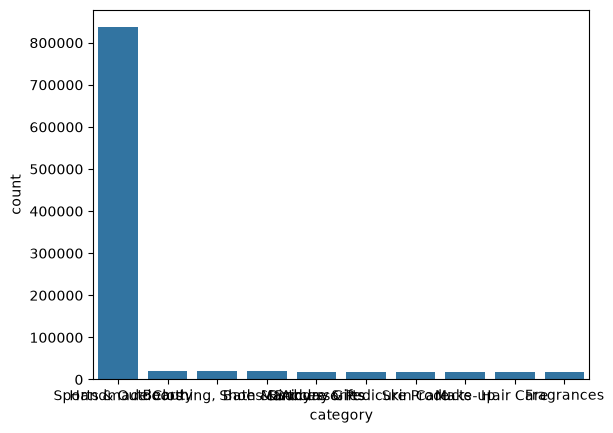

In [44]:
#Part1-2
df_cat_freq = df["category"].value_counts()[0:10].reset_index()
df_cat_freq.columns = ["category", "count"]
sns.barplot(
    x='category',
    y='count',
    data=df_cat_freq,
    legend=True,
)
plt.show()

In [54]:
#Part1-2
df_cat_prop=df["category"].value_counts(normalize=True)*100
df_cat_prop


category
Sports & Outdoors                         34.221949
Beauty                                     0.790293
Handmade Clothing, Shoes & Accessories     0.786896
Bath & Body                                0.781290
Birthday Gifts                             0.776625
                                            ...    
Motorbike Chassis                          0.004379
Alexa Built-In Devices                     0.004379
Plugs                                      0.004379
Smart Home Security & Lighting             0.004256
Smart Speakers                             0.002210
Name: proportion, Length: 296, dtype: float64

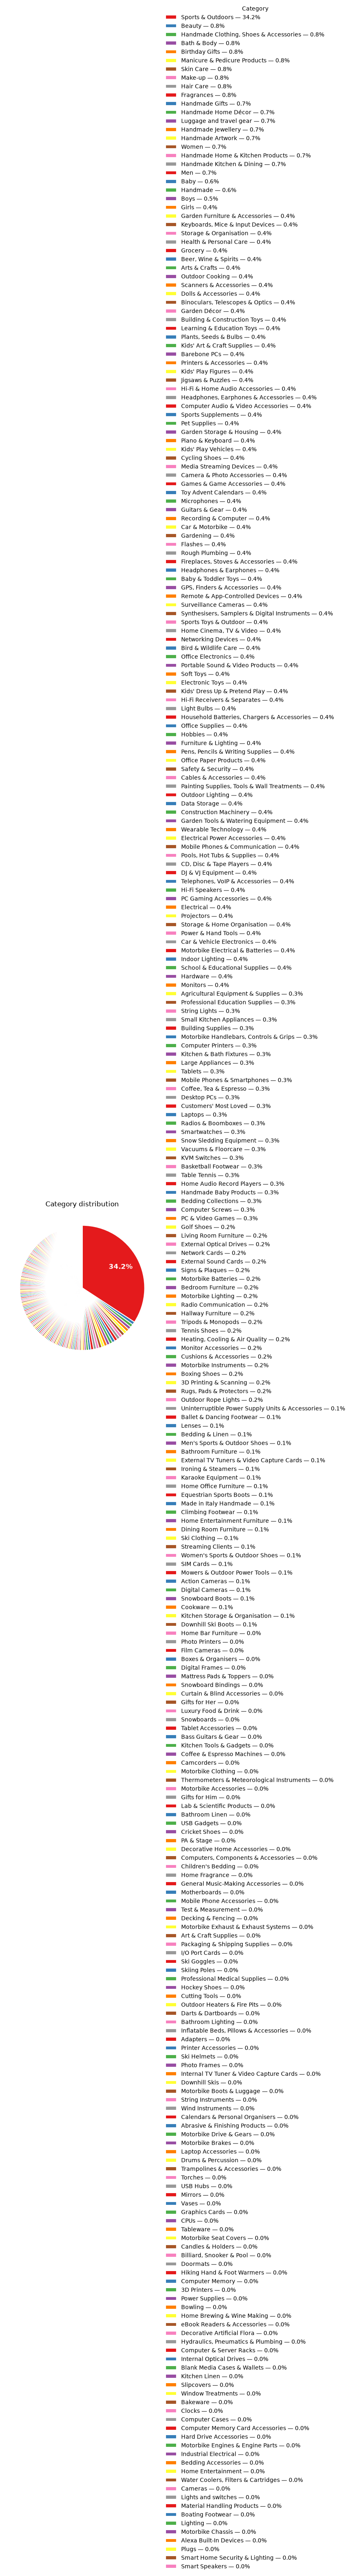

In [56]:
fig, ax = plt.subplots(figsize=(7, 5))
wedges, _, _ = ax.pie(
    cat_freq,
    startangle=90,
    counterclock=False,
    colors=sns.color_palette('Set1'),
    autopct=lambda p: f'{p:.1f}%' if p >= 5 else '',  # skip the slices too thin to hold text
    pctdistance=0.7,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'},
)

ax.legend(
    wedges,
    [f'{label} — {p:.1f}%' for label, p in df_cat_prop.items()],
    title='Category',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False,
)

ax.set_title('Category distribution')
plt.show()

In [57]:
#part2-1
df.price.describe()

count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64

In [ ]:
#part2-1
df.price.mode()

0    9.99
Name: price, dtype: float64

**part2-1**
The average price is 89.2, which is much higher than the most frequent price (mode) of 9.99 and the median of 19.09. The median indicates that approximately 50% of the prices are at or below 19.09. The fact that the mean is much higher than both the median and the mode indicates a strongly right-skewed distribution.

In [60]:
#Part2-2
print(f' The Interquartile Range is:{df.price.quantile(0.75)-df.price.quantile(0.25)}')
print(f' The Range is:{df.price.max()-df.price.min()}')
print(f' The Variance is:{df.price.var()}')
print(f' The Standard deviation is:{df.price.std()}')

 The Interquartile Range is:36.0
 The Range is:100000.0
 The Variance is:119445.48532254901
 The Standard deviation is:345.60886175349873


The standard deviation is 345.60, which indicates a large spread of the prices around the mean of 89.2. However, the standard deviation does not mean that each observation differs from the mean by exactly 345.60; rather, it summarizes the overall variability of the prices around the mean.

The range is 100,000, which also indicates a very large spread between the minimum and maximum prices. Together with the much smaller IQR of 36, this suggests that the large standard deviation and range are strongly influenced by extreme values or outliers.

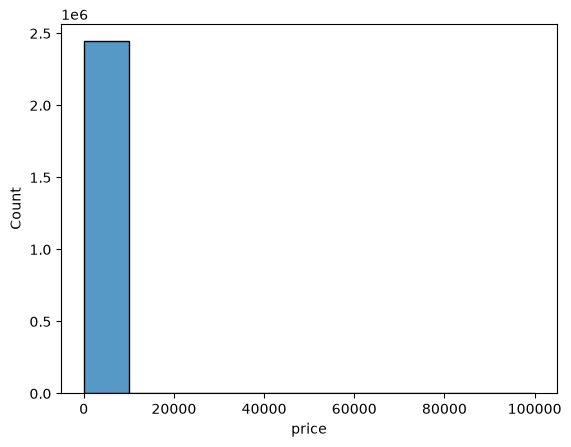

In [65]:
#part2-3
sns.histplot(df.price, bins=10)
plt.show()

The histogram also confirms that the price distribution is strongly right-skewed. Most prices are concentrated between 0 and 10,000, while a small number of very high prices create a long right tail.

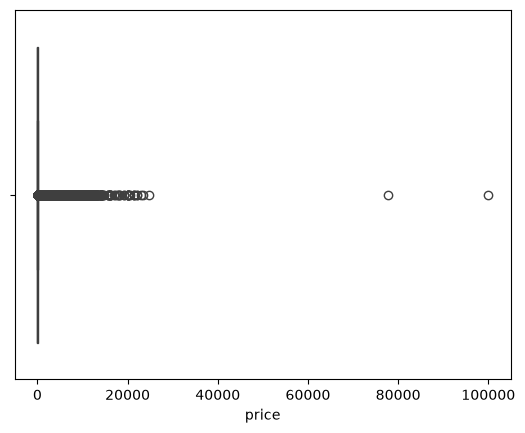

In [66]:
sns.boxplot(data=df, x="price")
plt.show()

There are two particularly high prices, around 80,000 and 100,000, which appear to be outliers and are much higher than the rest of the prices.

In [89]:
#Part3-1
print(f' The Averae is: {df.stars.mean()}')
print(f' The Median is: {df.stars.median()}')
print(f' The Mode is: {df.stars.mode()}')

 The Averae is: 2.152836472966066
 The Median is: 0.0
 The Mode is: 0    0.0
Name: stars, dtype: float64


The average star rating is approximately 2.15. However, both the median and the mode are 0, meaning that at least half of the products have a recorded star rating of 0 and 0 is the most frequent value.

Since customer ratings are normally given on a scale from 1 to 5 stars, the large number of zero values may represent products that have not yet received any ratings rather than actual zero-star ratings. Therefore, Lets calculate the results after removing zeros as well.

In [ ]:
df_new=df[df.reviews>0]

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443642,2828585,B07DCFQMQL,Speed MaxX BODY ARMOUR CE MOTORBIKE/MOTORCYCLE...,3.6,66,49.99,False,0,Motorbike Clothing
2443643,2828586,B07JM5VQFX,Motorcycle Clothing Suit - Motorbike Suit With...,4.1,5,158.99,False,0,Motorbike Clothing
2443644,2828587,B07X98JLFF,GREAT BIKERS GEAR - Bobber Cafe Brat Style Lea...,3.6,12,14.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [90]:
print(f' The Averae is: {df_new.stars.mean()}')
print(f' The Median is: {df_new.stars.median()}')
print(f' The Mode is: {df_new.stars.mode()}')

 The Averae is: 4.319160762226911
 The Median is: 4.4
 The Mode is: 0    4.5
Name: stars, dtype: float64


After removing the zero values, the results changed substantially. The mean, median, and mode are all close to 4.4, suggesting that the distribution of the non-zero ratings is relatively concentrated and may be fairly symmetric. Since the ratings are close to the upper end of the scale, this also suggests that customers who provided ratings were generally satisfied with the products they purchased.

In [91]:
#part3-2
print(f' The Interquartile Range is:{df_new.stars.quantile(0.75)-df_new.stars.quantile(0.25)}')
print(f' The Range is:{df_new.stars.max()-df_new.stars.min()}')
print(f' The Variance is:{df_new.stars.var()}')
print(f' The Standard deviation is:{df_new.stars.std()}')

 The Interquartile Range is:0.5
 The Range is:4.0
 The Variance is:0.3083433752387284
 The Standard deviation is:0.5552867504620729


The ratings show relatively low variability after removing the zero values. The interquartile range is 0.5, meaning that the middle 50% of the ratings are concentrated within only half a star. The standard deviation is approximately 0.56, which also indicates that most ratings are relatively close to the mean

In [101]:
#Part3-3
print("Skewness:", df_new["stars"].skew())
print("Kurtosis:", df_new["stars"].kurt())

Skewness: -2.379568112212799
Kurtosis: 9.78193769066435


The skewness is approximately −2.38, indicating a strongly left-skewed distribution. Most ratings are concentrated at the higher end of the scale, while a smaller number of low ratings create a long left tail.

The kurtosis is approximately 9.78, which is much higher than 0 and indicates more extreme values than a normal distribution.

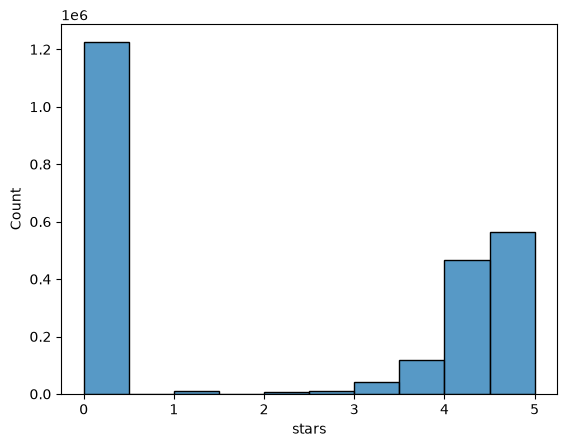

In [93]:
#Part3-4
sns.histplot(df.stars, bins=10)
plt.show()

Including the zero values, the distribution appears to be a mixture of two components: a large concentration at zero and a separate distribution of positive star ratings. The zero values may represent products without ratings, while the positive values represent actual customer ratings.

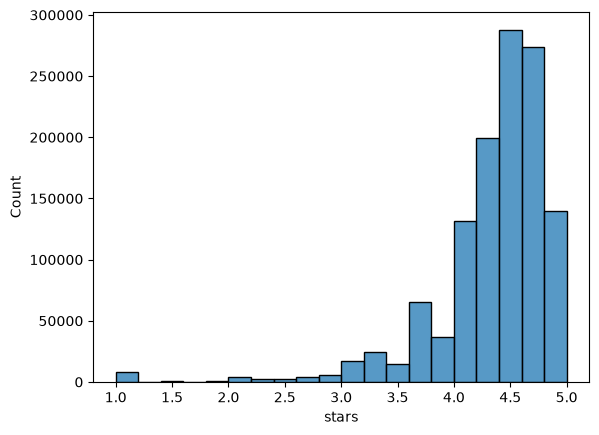

In [100]:
sns.histplot(df_new.stars, bins=20)
plt.show()

A rating of around 4.5 is more common than the other ratings in the non-zero data.